In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.shape

(7043, 21)

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
df.describe().round()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Num
count,7032.0,7032.0,7032.0,7032.0,7032.0
mean,0.0,32.0,65.0,2283.0,0.0
std,0.0,25.0,30.0,2267.0,0.0
min,0.0,1.0,18.0,19.0,0.0
25%,0.0,9.0,36.0,401.0,0.0
50%,0.0,29.0,70.0,1397.0,0.0
75%,0.0,55.0,90.0,3795.0,1.0
max,1.0,72.0,119.0,8685.0,1.0


Data Cleaning

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [4]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.shape

(7032, 21)

In [22]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop('customerID', axis=1, inplace=True)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

Exploratory Data Analysis (EDA)

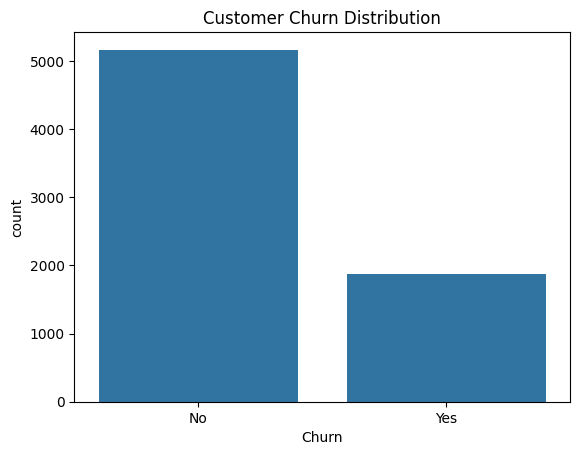

In [26]:
sns.countplot(
    x='Churn',
    data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [27]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

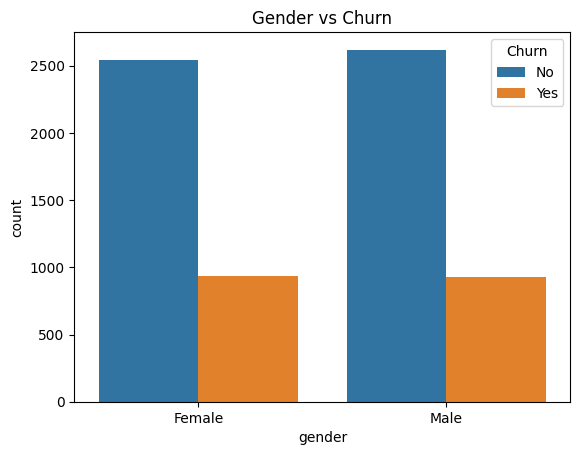

In [28]:
sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)
plt.title("Gender vs Churn")
plt.show()

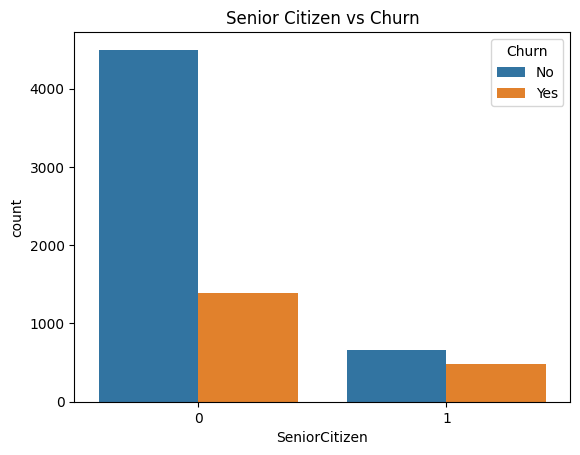

In [29]:
sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

plt.title("Senior Citizen vs Churn")
plt.show()

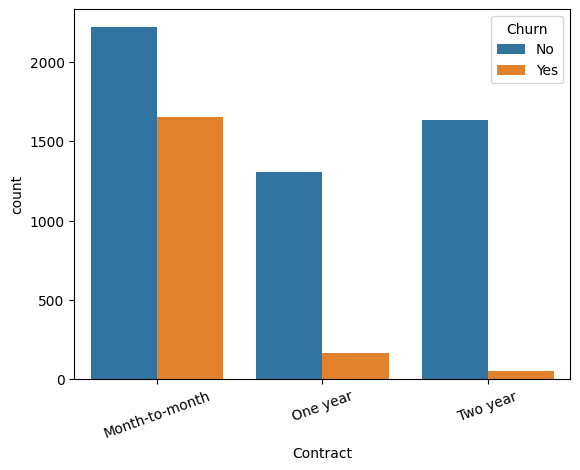

In [30]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.xticks(rotation=20)
plt.show()

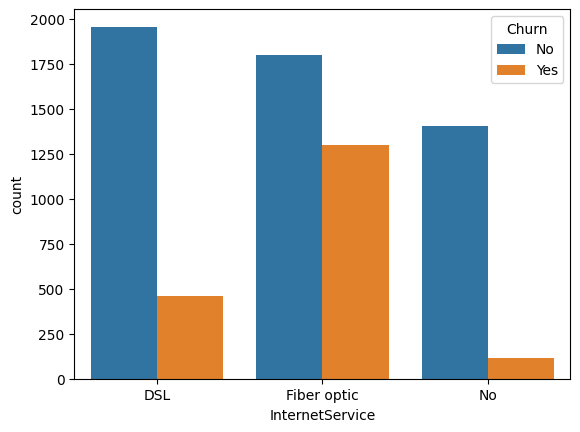

In [31]:
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)
plt.show()

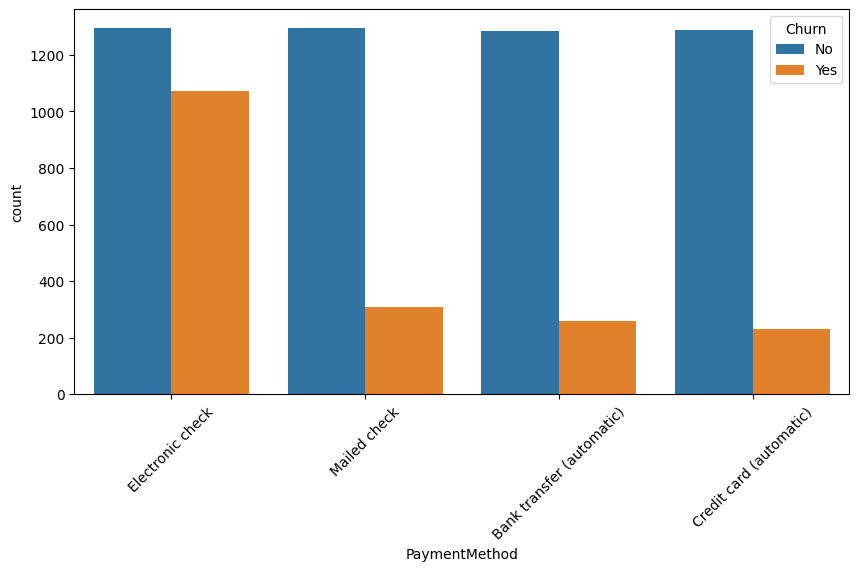

In [32]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=45)
plt.show()

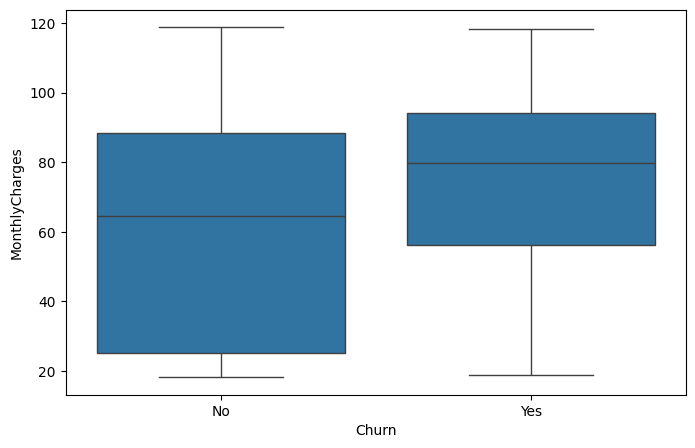

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)
plt.show()

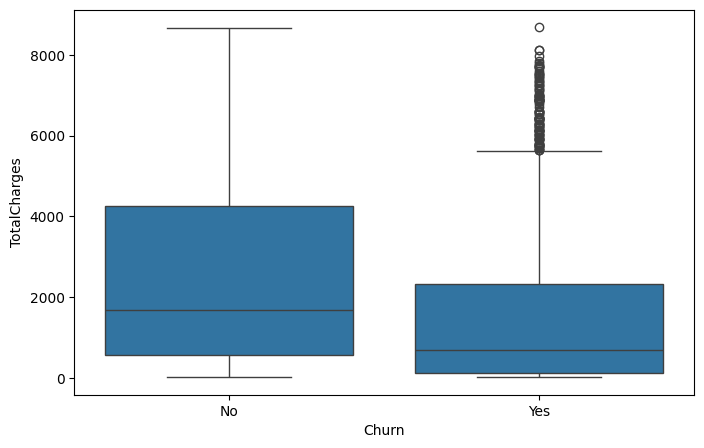

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df
)

plt.show()

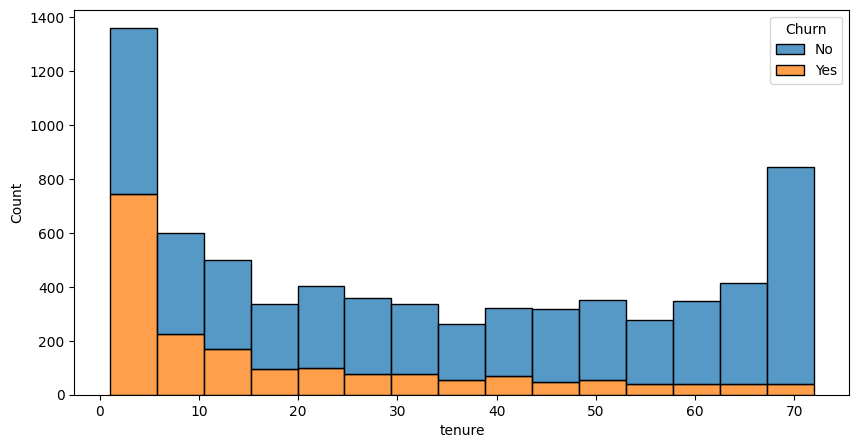

In [35]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    multiple='stack'
)

plt.show()

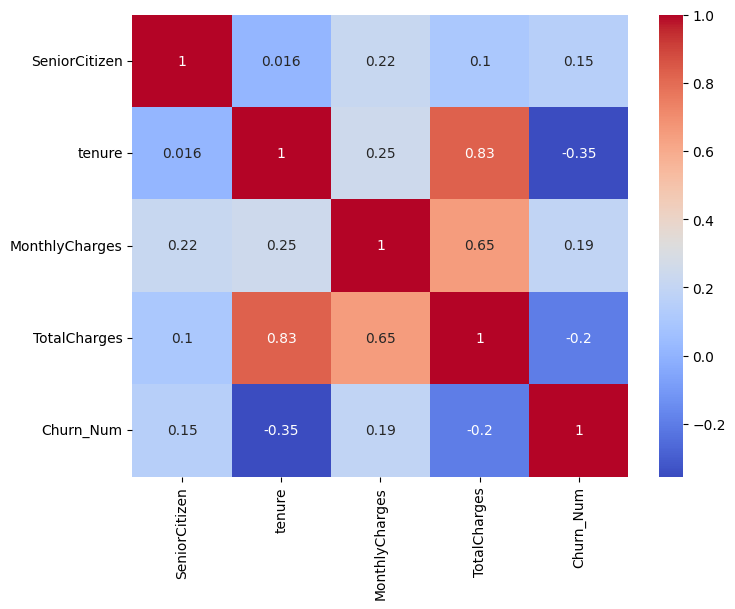

In [37]:
df['Churn_Num'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

corr = df.select_dtypes(
    include=['int64','float64']
).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

Feature Engineering

In [39]:
#Check Target Variable
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [51]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

df["Churn"].head()


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Churn, dtype: float64

In [42]:
df.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [43]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Churn_Num,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,NaN,0,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,NaN,0,True,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,NaN,1,True,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,NaN,0,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,NaN,1,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False


Train-Test Split

In [45]:
X = df.drop("Churn",axis=1)

y = df["Churn"]

In [52]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
df["Churn"].unique()

array([0, 1])

In [11]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [12]:
df["Churn"].unique()

array([0, 1])

Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split

# Features (Input Variables)
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [40]:
# Split Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (5625, 30)
Test Shape: (1407, 30)


Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

# Fit and Transform Training Data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed Successfully!")

Scaling Completed Successfully!


Train Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

# Create Model
lr_model = LogisticRegression(random_state=42)
# Train Model
lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [ ]:
Make Predictions

In [46]:
y_pred_lr = lr_model.predict(X_test)

print(y_pred_lr[:10])

[0 0 1 0 0 0 0 1 0 0]


Check Accuracy

In [47]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.7874911158493249


In [ ]:
Classification Report

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Confusion Matrix

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[915 118]
 [181 193]]


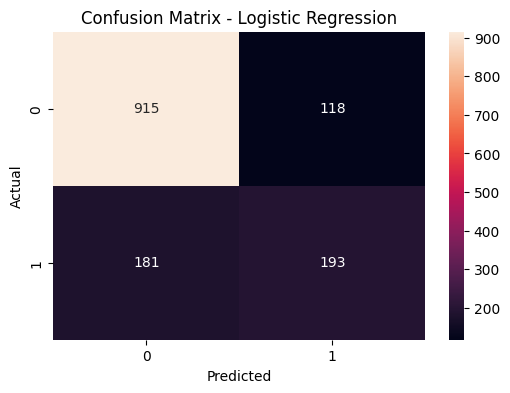

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Train Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [52]:
#Random Forest Predictions
y_pred_rf = rf_model.predict(X_test)

In [53]:
#Random Forest Accuracy
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7846481876332623


In [54]:
#Compare Models
print("Logistic Regression Accuracy :", accuracy_lr)
print("Random Forest Accuracy       :", accuracy_rf)

Logistic Regression Accuracy : 0.7874911158493249
Random Forest Accuracy       : 0.7846481876332623


In [55]:
#Generating Classification Report for Best Model
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [56]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[915 118]
 [181 193]]


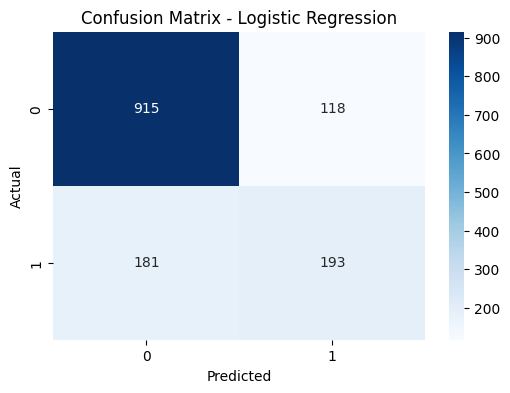

In [57]:
#Plot Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [58]:
#Feature Importance / Coefficients
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)
feature_importance.head(10)

,Feature,Coefficient
3,TotalCharges,0.694885
10,InternetService_Fiber optic,0.650749
23,StreamingMovies_Yes,0.222440
21,StreamingTV_Yes,0.212963
9,MultipleLines_Yes,0.160546
26,PaperlessBilling_Yes,0.134580
28,PaymentMethod_Electronic check,0.123558
0,SeniorCitizen,0.094976
17,DeviceProtection_Yes,0.040129
8,MultipleLines_No phone service,0.029736


In [59]:
import joblib

joblib.dump(lr_model,'logistic_regression_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


Project Summary

This project aimed to predict customer churn using machine learning techniques. Two models were trained and evaluated:

Logistic Regression
Random Forest

The Logistic Regression model achieved the highest accuracy of 78.75% and was selected as the final model.

Key Insights

1. Customers with Higher Monthly Charges are More Likely to Churn
2. Customers with Short Tenure Have Higher Churn Risk
3. Contract Type Influences Customer Retention
4. Lack of Additional Services Increases Churn
5. Churn Prediction Can Help Reduce Revenue Loss

Model Performance
Model	Accuracy
Logistic Regression	78.75%
Random Forest	78.46%

Selected Model: Logistic Regression